# QRcode

In [1]:
import tkinter as tk
import qrcode
import matplotlib.pyplot as plt
from qrcode.constants import ERROR_CORRECT_H
from qrcode.image.styledpil import StyledPilImage
from qrcode.main import QRCode
from PIL import Image, ImageTk
from pathlib import Path

## QRcode로 문자입력

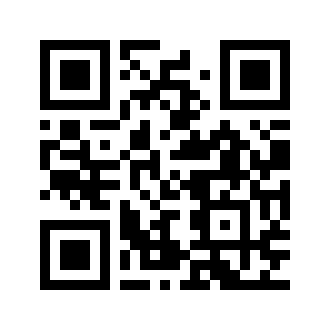

In [3]:
img = qrcode.make("헬로, QR 코드!")
img

## QRcode로 웹사이트 방문

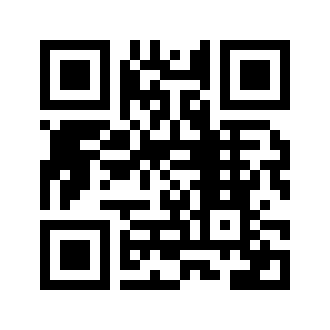

In [4]:
img_youtube = qrcode.make("https://www.youtube.com/")
img_youtube

## QRcode의 색상넣기

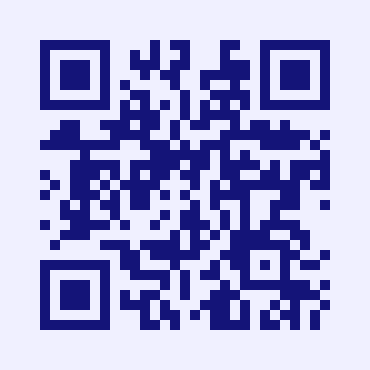

In [ ]:
def make_qr(data, save_path, fill_color="black", back_color="white"):
    qr = qrcode.QRCode(
        error_correction=qrcode.constants.ERROR_CORRECT_H
    )
    qr.add_data(data)
    qr.make()

    img = qr.make_image(
        fill_color=fill_color,
        back_color=back_color
    ).convert("RGB")

    img.save(save_path)
    return img


# 실행
img = make_qr(
    "https://www.youtube.com/",
    "youtube_qr.png",           # 만들어진 QRcode 그림으로 만들기
    fill_color=(20,20,120),
    back_color=(240,240,255)
)

img

## QRcode에 그림 넣기

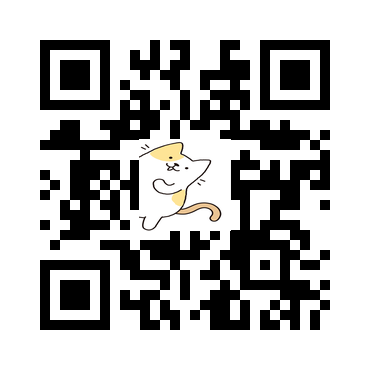

In [ ]:
qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H)
qr.add_data("https://www.youtube.com/")
qr.make()

img_qr = qr.make_image(fill_color="black", back_color="white").convert("RGB")

# logo_path = IN_DIR / "cat.png"
logo_path = Path("../../data/cat.png")
logo = Image.open(logo_path)

qr_width, qr_height = img_qr.size
logo_size = qr_width // 4   # QRcode의 한변 크기의 1/4
logo = logo.resize((logo_size, logo_size), Image.LANCZOS)   # LANCZOS : 이미지 화질을 최대한 보전

pos = ((qr_width - logo_size) // 2, (qr_height - logo_size) // 2)   # QRcode 중심에 이미지 중심을 위치시킴
img_qr.paste(logo, pos, mask=logo if logo.mode == 'RGBA' else None)

img_qr

## 명함 QRcode

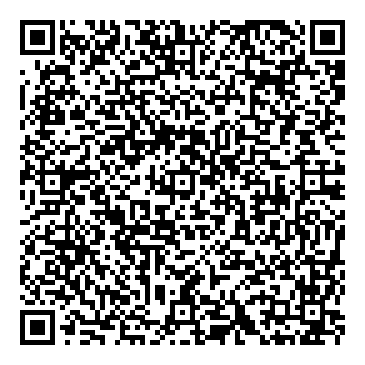

In [7]:
## 명함 QRcode

def make_vcard_qr(
    name,
    phone,
    email,
    company="",
    title="",
    website="",
    save_path="business_card_qr.png",
    box_size=5,     # 크기
    border=4         # 여백
):
    # vCard 형식 만들기
    vcard = f"""BEGIN:VCARD
VERSION:3.0
FN:{name}
ORG:{company}
TITLE:{title}
TEL:{phone}
EMAIL:{email}
URL:{website}
END:VCARD
"""
    qr = qrcode.QRCode(
        error_correction=qrcode.constants.ERROR_CORRECT_H,
        box_size=box_size,     # 크기
        border=border          # 여백
    )
    qr.add_data(vcard)
    qr.make()

    img = qr.make_image(fill_color="black", back_color="white").convert("RGB")
    img.save(save_path)

    return img

# 예시
img = make_vcard_qr(
    name="홍길동",
    phone="010-1234-5678",
    email="hong@example.com",
    company="ABC Company",
    title="Data Analyst",
    website="https://example.com",
    save_path="hong_business_qr.png"
)

img

## wifi 연결 QRcode

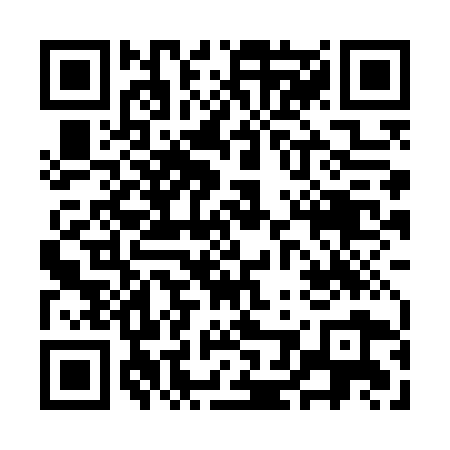

In [8]:
## 와이파이 연결 QRcode

def make_wifi_qr(ssid, password, encryption='WPA', hidden=False, save_path='wifi_qr.png', box_size=10, border=4):
    """
    Wi-Fi QR 코드 생성
    """
    hidden_str = 'true' if hidden else 'false'
    wifi_data = f"WIFI:T:{encryption};S:{ssid};P:{password};H:{hidden_str};;"

    qr = qrcode.QRCode(
        error_correction=qrcode.constants.ERROR_CORRECT_H,
        box_size=box_size,
        border=border
    )
    qr.add_data(wifi_data)
    qr.make()

    img = qr.make_image(fill_color="black", back_color="white").convert("RGB")
    img.save(save_path)
    return img

# 예시
img = make_wifi_qr(
    ssid="MyWiFi",
    password="12345678",
    encryption="WPA",
    save_path="mywifi_qr.png"
)

img

## tkinter를 이용한 QRcode 생성기

In [6]:
## Tkinter와 QRcode

def generate_qr():
    # QR 코드 생성
    qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H)
    qr.add_data("https://www.youtube.com/")
    qr.make()
    img_qr = qr.make_image(fill_color="black", back_color="white").convert("RGB")
    img_qr.save("youtube_qr.png")
    
    # 로고 삽입
    logo_path = Path("../../data/cat.png")
    logo = Image.open(logo_path)

    qr_width, qr_height = img_qr.size
    logo_size = qr_width // 4
    logo = logo.resize((logo_size, logo_size), Image.LANCZOS)

    pos = ((qr_width - logo_size) // 2, (qr_height - logo_size) // 2)
    img_qr.paste(logo, pos, mask=logo if logo.mode == 'RGBA' else None)

    # tkinter 이미지로 변환 후 라벨에 표시
    img_tk = ImageTk.PhotoImage(img_qr)
    qr_label.config(image=img_tk)
    qr_label.image = img_tk

def clear_qr():
    qr_label.config(image='')
    qr_label.image = None

# GUI 초기화
root = tk.Tk()
root.title("QR 코드 생성기")

# 버튼 프레임
button_frame = tk.Frame(root)
button_frame.pack(pady=10)

# 생성 버튼
generate_button = tk.Button(button_frame, text="QR 코드 생성", command=generate_qr)
generate_button.pack(side=tk.LEFT, padx=5)

# 삭제 버튼
clear_button = tk.Button(button_frame, text="QR 코드 삭제", command=clear_qr)
clear_button.pack(side=tk.LEFT, padx=5)

# QR 코드 표시용 라벨
qr_label = tk.Label(root)
qr_label.pack(pady=10)

# GUI 실행
root.mainloop()

## tkinter를 이용하여 QRcode만들기 2

In [3]:
import qrcode
from PIL import Image, ImageTk
import tkinter as tk
from tkinter import messagebox, filedialog
from pathlib import Path

def generate_qr():
    url = url_entry.get().strip()
    if not url:
        messagebox.showwarning("입력 오류", "URL을 입력하세요.")
        return

    try:
        # QR 코드 생성
        qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H)
        qr.add_data(url)
        qr.make()
        img_qr = qr.make_image(fill_color="black", back_color="white").convert("RGB")

        # 로고 삽입 여부 확인
        if use_logo_var.get():
            logo_path = Path("../../data/cat.png")
            if not logo_path.exists():
                messagebox.showerror("로고 오류", f"로고 파일이 없습니다: {logo_path}")
                return
            logo = Image.open(logo_path)

            qr_width, qr_height = img_qr.size
            logo_size = qr_width // 4
            logo = logo.resize((logo_size, logo_size), Image.LANCZOS)

            pos = ((qr_width - logo_size) // 2, (qr_height - logo_size) // 2)
            img_qr.paste(logo, pos, mask=logo if logo.mode == 'RGBA' else None)

        # tkinter용 이미지로 변환
        img_tk = ImageTk.PhotoImage(img_qr)
        qr_label.config(image=img_tk)
        qr_label.image = img_tk
        url_display.config(text=url)
        global current_qr_image
        current_qr_image = img_qr

    except Exception as e:
        messagebox.showerror("오류 발생", str(e))

def clear_qr():
    qr_label.config(image='')
    qr_label.image = None
    url_display.config(text="")
    url_entry.delete(0, tk.END)

def save_qr():
    if not current_qr_image:
        messagebox.showinfo("저장 실패", "먼저 QR 코드를 생성하세요.")
        return

    filepath = filedialog.asksaveasfilename(
        defaultextension=".png",
        filetypes=[("PNG 파일", "*.png")],
        title="QR 코드 저장"
    )
    if filepath:
        current_qr_image.save(filepath)
        messagebox.showinfo("저장 완료", f"QR 코드가 저장되었습니다:\n{filepath}")

# 전역 변수 초기화
current_qr_image = None

# GUI 초기화
root = tk.Tk()
root.title("QR 코드 생성기")
root.resizable(False, False)

# URL 입력 라벨 및 입력창
tk.Label(root, text="URL 입력:").pack(anchor='w', padx=10, pady=(10, 0))
url_entry = tk.Entry(root, width=50)
url_entry.pack(padx=10, pady=5)

# 로고 삽입 체크박스
use_logo_var = tk.BooleanVar(value=True)
logo_checkbox = tk.Checkbutton(root, text="로고 삽입", variable=use_logo_var)
logo_checkbox.pack(pady=(0, 10))

# 버튼들을 가로로 배치할 Frame
button_frame = tk.Frame(root)
button_frame.pack(pady=5)

generate_button = tk.Button(button_frame, text="QR 생성", width=12, command=generate_qr)
generate_button.pack(side=tk.LEFT, padx=5)

clear_button = tk.Button(button_frame, text="QR 삭제", width=12, command=clear_qr)
clear_button.pack(side=tk.LEFT, padx=5)

save_button = tk.Button(button_frame, text="QR 저장", width=12, command=save_qr)
save_button.pack(side=tk.LEFT, padx=5)

# QR 이미지 표시 라벨
qr_label = tk.Label(root)
qr_label.pack(pady=10)

# URL 표시 라벨
url_display = tk.Label(root, text="", fg="blue")
url_display.pack(pady=(0, 10))

# GUI 실행
root.mainloop()
